# Two-Spin Quantum Simulation with Qiskit

In [ ]:
# =============================================================================
# Project: Two-Spin Quantum Simulation with Qiskit
# Author : Fahim Faisal
#
# Description:
# This project demonstrates:
#   1. Preparation of the Bell State |Ψ⁻⟩
#   2. State measurement using SamplerV2
#   3. Energy estimation using EstimatorV2
#   4. Comparison between real quantum hardware and quantum simulator results
#
# Bell State:
#   |Ψ⁻⟩ = (|01⟩ - |10⟩)/√2
#
# Hamiltonian:
#   H = J(Z₁Z₀) + hx(X₁ + X₀)
#
# =============================================================================

##  Section 1: Import Required Libraries

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator
)

## Section 2: Prepare The BELL STATE |Ψ⁻⟩

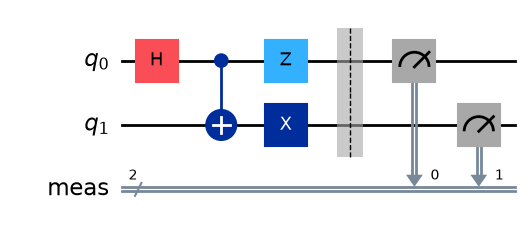

In [3]:
# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

## Section 3: Load IBM QUANTUM SERVICE

In [4]:
# =============================================================================
#
# Purpose:
# Connect to IBM Quantum Platform and select
# an available quantum processor.
#
# =============================================================================

# load zthe saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-23 07:45:54,265: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Fahim Faisal. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 07:45:54,565: Loading instance: Fahim Faisal, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-23 07:45:58,018: Using instance: Fahim Faisal, plan: open


ibm_kingston


## Section 4. Circuit Optimization (Transpilation)

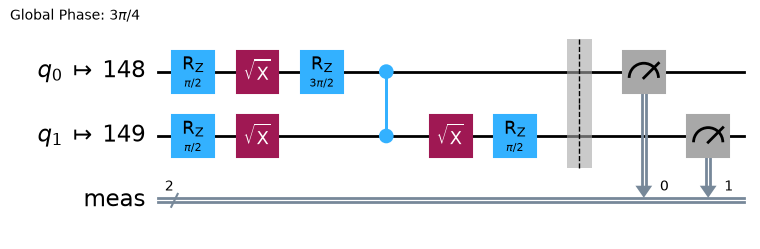

In [5]:
# =============================================================================
#
# Purpose:
# Convert the abstract quantum circuit into a hardware-compatible circuit.
#
# Optimization Level 3:
# Highest built-in optimization level.
#
# =============================================================================

# Transpile the circuit and optimize for running on the quantum computer selected

# Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

## Section 5: Execution

In [9]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

### Using Simulator

In [10]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)


job_sim = sampler_sim.run([qc_isa]) 
res_sim = job_sim.result()
counts_sim = res_sim[0].data.meas.get_counts()

## Section 6: Visualization of Results

### Using Quantum Computer

In [11]:
job = sampler.run([qc_isa], shots=100)
res = job.result()
counts = res[0].data.meas.get_counts()

counts =  {'10': 46, '01': 52, '00': 1, '11': 1}


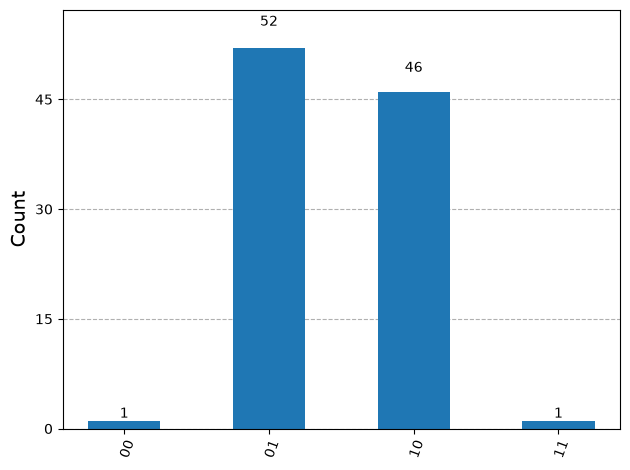

In [12]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

### Using Quantum Simulator

counts =  {'10': 501, '01': 515, '00': 4, '11': 4}


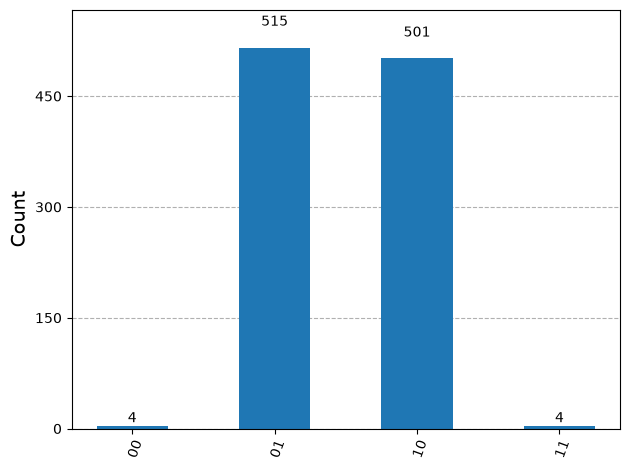

In [13]:
from qiskit.visualization import plot_histogram

print("counts = ", counts_sim)
plot_histogram(counts_sim)

## Section 7: Prepare Bell State for Energy Calculation

In [17]:
# Import Qiskit primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J<0)
hx = -0.5  # transverse field strength

# Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

## Section 8: Optimization

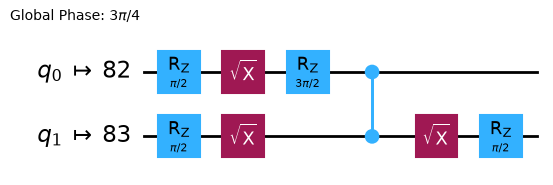

In [18]:
# Transpile the circuit and optimize for running on the quantum computer selected

# Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

## Section 9: Energy Estimation 

### Using Real Quantum Hardware

In [19]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [20]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

In [ ]:
print(res[0].data.evs)

-0.9788472756349285


### Using Real Quantum Simulator

In [33]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [34]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)

0.47.0


In [41]:
# Load the backend sampler

noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
from qiskit.primitives import BackendEstimatorV2
estimator_sim = BackendEstimatorV2(backend=backend_sim)


In [45]:
# the Aer simulator with noise model from real backend

job2 = estimator_sim.run([[qc,obs]])
res2 = job2.result()
print(res2[0].data.evs)

-1.0
